In [112]:
import os
import sys
import numpy as np
import xarray as xr
import geopandas as gpd
import shapely.vectorized as sv

import cartopy.crs as ccrs
import cartopy.feature as cfeature

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.gridspec as gridspec

import sys
sys.path.append(os.path.abspath("../.."))
from function import DOWN_raw
from function import ART_downscale

## Verify BETA values from BETA_v2.py

In [113]:
# PADOVA
# lon_min, lon_max, lat_min, lat_max, area = 11, 12.5, 45, 46, 'PADOVA'
# VENETO
lon_min, lon_max, lat_min, lat_max, area = 10.5, 13.5, 44.5, 47, 'VENETO'
# ITALY
# lon_min, lon_max, lat_min, lat_max, area = 6.5, 19, 36.5, 48, 'ITALY'

npix = 2

In [114]:
# product, time_reso = 'IMERG', '3h'
# product, time_reso = 'CMORPH', '3h'
# product, time_reso = 'MSWEP', '3h'
# product, time_reso = 'ERA5', '3h'
# product, time_reso = 'GSMaP', '3h'
product, time_reso = 'CHIRPS', '1dy'

In [115]:
dir_base = os.path.join('..','..','output','Beta')
data_dir = os.path.join(dir_base,f'{area}_Beta_{product}_{time_reso}_2002_2023_npix_{npix}.nc')
DATA = xr.open_dataset(data_dir)

lons, lats = DATA.lon.values, DATA.lat.values
lon2d, lat2d = np.meshgrid(lons, lats)
Beta = DATA.BETA.values

mask_beta = np.isnan(Beta)

In [116]:
if area == 'PADOVA':
    GEOMETRY = gpd.read_file(os.path.join('..','..', 'geometry','Padova.geojson'))
elif area == 'VENETO':
    GEOMETRY = gpd.read_file(os.path.join('..','..', 'geometry','Veneto.geojson'))
elif area == 'ITALY':
    GEOMETRY = gpd.read_file(os.path.join('..','..', 'geometry','Italy_simple.geojson'))
else:
    sys.exit("Area not recognized. Please choose 'VENETO' or 'ITALY'.")

GEOMETRY_union = GEOMETRY.unary_union

/tmp/ipykernel_46101/726573604.py:10: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  GEOMETRY_union = GEOMETRY.unary_union


In [117]:
lat_pos, lon_pos = np.where(Beta==np.nanmin(Beta))
print(f"Beta MIN: {np.nanmin(Beta)}")
print(f"index lat and lon: {lat_pos[0]}, {lon_pos[0]}")
print(f'Lat: {lats[lat_pos[0]]}')
print(f'Lon: {lons[lon_pos[0]]}')

Beta MIN: 1.0876683541234315
index lat and lon: 55, 62
Lat: 45.774993896484375
Lon: 12.125


In [118]:
lat_pos, lon_pos = np.where(Beta==np.nanmax(Beta))
print(f"Beta MAX: {np.nanmax(Beta)}")
print(f"index lat and lon: {lat_pos[0]}, {lon_pos[0]}")
print(f'Lat: {lats[lat_pos[0]]}')
print(f'Lon: {lons[lon_pos[0]]}')

Beta MAX: 1.8360037643474951
index lat and lon: 39, 70
Lat: 44.974998474121094
Lon: 12.524993896484375


In [119]:
# test for CHIRPS
# Beta = np.where(Beta>=1.14,np.nan,Beta)

Text(1.0, 1.0, 'CHIRPS')

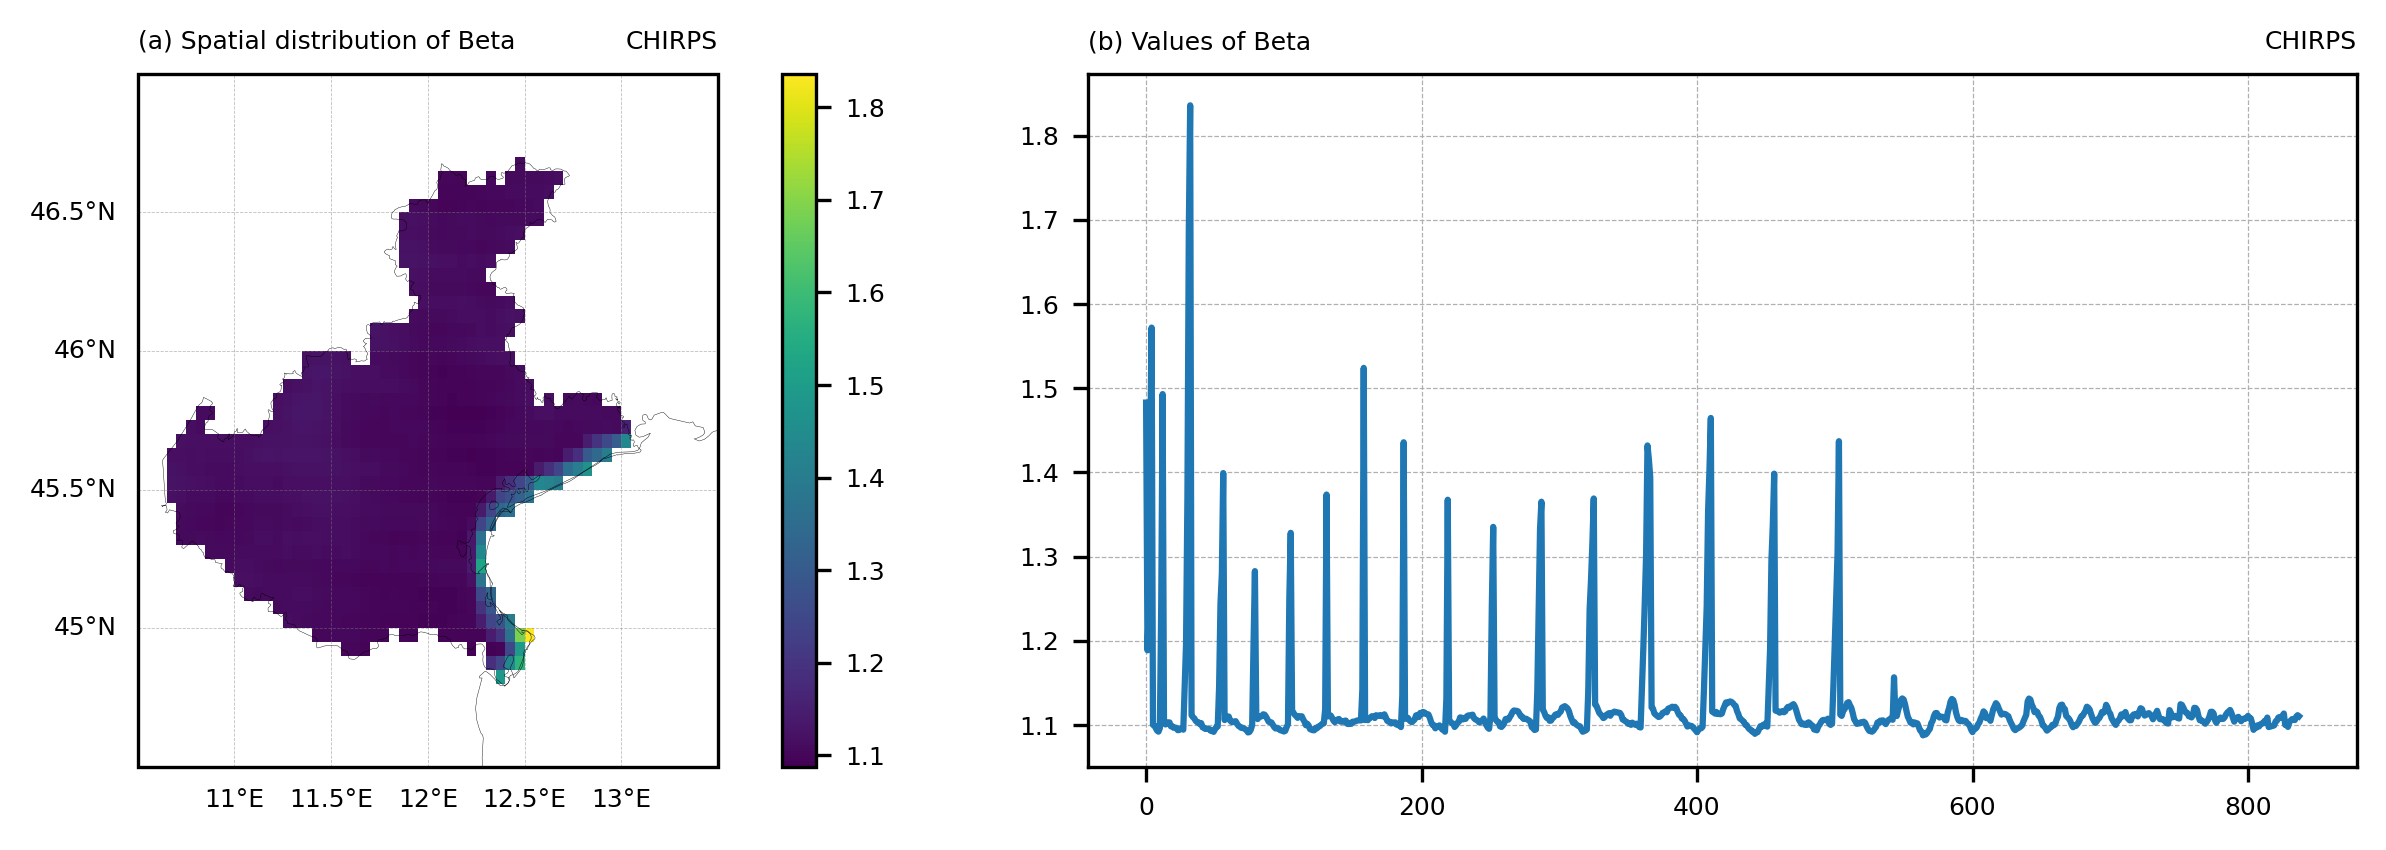

In [120]:
proj = ccrs.PlateCarree()

fig = plt.figure(figsize=(12,3),dpi=300)
gs = gridspec.GridSpec(1,2)

# ========================================================================================================
ax1 = plt.subplot(gs[0, 0], projection = proj)
ax1.set_extent([lon_min, lon_max, lat_min, lat_max], crs=proj)
ax1.add_feature(cfeature.COASTLINE,linewidth=0.1,edgecolor='k')
GEOMETRY.plot(legend=False, facecolor="none", edgecolor='black', linewidth=0.1, ax=ax1, zorder=10)
a1 = ax1.pcolormesh(lon2d, lat2d, Beta)
cbar = plt.colorbar(a1, fraction =0.042)
cbar.ax.tick_params(labelsize=6)

gl = ax1.gridlines(crs=proj,draw_labels=True,linewidth=0.2,color='gray',alpha=0.5,linestyle='--')
gl.top_labels = False
gl.bottom_labels = True
gl.left_labels = True
gl.right_labels = False
gl.xlabel_style = {'size': 6, 'color': 'k'}
gl.ylabel_style = {'size': 6, 'color': 'k'}

ax1.set_title('(a) Spatial distribution of Beta', loc='left', fontsize=6)
ax1.set_title(product, loc='right', fontsize=6)

# ========================================================================================================
ax1 = plt.subplot(gs[0, 1])
ax1.plot(Beta[~np.isnan(Beta)])

ax1.set_title('(b) Values of Beta', loc='left', fontsize=6)
ax1.tick_params(axis='both', which='major', labelsize=6)
ax1.grid(linewidth=0.3, linestyle='--')
ax1.set_title(product, loc='right', fontsize=6)

In [121]:
dir_base = f'/media/arturo/T9/Data/Italy/Satellite/2_MEV/uncorrected/ITALY_DOWN_{product}_{time_reso}_2002_2023_npix_{npix}_thr_1_acf_mar_genetic_pearson.nc'
DATA_base = xr.open_dataset(dir_base)

DATA_base_crop = DATA_base.sel(lon=DATA.lon,lat=DATA.lat,method="nearest")

BETA_old = DATA_base_crop.BETA.values
GAMMA_old = DATA_base_crop.GAMMA.values
MEVD_old = DATA_base_crop.Mev_d.values

NYs = DATA_base_crop.NYs.values
CYs = DATA_base_crop.CYs.values
WYs = DATA_base_crop.WYs.values

BETA_old[mask_beta]  = np.nan
GAMMA_old[mask_beta] = np.nan

NYs[:, mask_beta] = np.nan
CYs[:, mask_beta] = np.nan
WYs[:, mask_beta] = np.nan

MEVD_old[:, mask_beta] = np.nan

In [127]:
if product == 'CHIRPS':
    print('Applying mask')
    mask_B_CHIRPS = np.isnan(BETA_old)
    Beta[mask_B_CHIRPS]  = np.nan

Applying mask


In [133]:
NYd_old, CYd_old, WYd_old = np.zeros([22,len(lats),len(lons)]), np.zeros([22,len(lats),len(lons)]), np.zeros([22,len(lats),len(lons)])
for i in range(len(lats)):
    for j in range(len(lons)):
        if np.isnan(NYs[:, i, j]).all() or np.all(NYs[:, i, j] == 0):
            NYd_old[:,i,j] = np.nan
            CYd_old[:,i,j] = np.nan
            WYd_old[:,i,j] = np.nan
        else:
            NYd_old_, CYd_old_, WYd_old_ = ART_downscale.down_wei_beta_alpha_update_v2(NYs[:,i,j], CYs[:,i,j], WYs[:,i,j], BETA_old[i,j], GAMMA_old[i,j])
            NYd_old[:,i,j] = NYd_old_
            CYd_old[:,i,j] = CYd_old_
            WYd_old[:,i,j] = WYd_old_

In [135]:
NYd_new, CYd_new, WYd_new = np.zeros([22,len(lats),len(lons)]), np.zeros([22,len(lats),len(lons)]), np.zeros([22,len(lats),len(lons)])
for i in range(len(lats)):
    for j in range(len(lons)):
        if np.isnan(NYs[:, i, j]).all() or np.all(NYs[:, i, j] == 0):
            NYd_new[:,i,j] = np.nan
            CYd_new[:,i,j] = np.nan
            WYd_new[:,i,j] = np.nan
        else:
            NYd_new_, CYd_new_, WYd_new_ = ART_downscale.down_wei_beta_alpha_update_v2(NYs[:,i,j], CYs[:,i,j], WYs[:,i,j], Beta[i,j], GAMMA_old[i,j])
            NYd_new[:,i,j] = NYd_new_
            CYd_new[:,i,j] = CYd_new_
            WYd_new[:,i,j] = WYd_new_

In [136]:
Tr = [5,  10,  20,  50, 100, 200]

MEVS_OLD = ART_downscale.pre_quantiles_array(NYs, CYs, WYs, Tr, lats, lons, 1)

MEVD_OLD = ART_downscale.pre_quantiles_array(NYd_old, CYd_old, WYd_old, Tr, lats, lons, 1)

MEVD_NEW = ART_downscale.pre_quantiles_array(NYd_new, CYd_new, WYd_new, Tr, lats, lons, 1)

/home/arturo/github/MEVD-downscaling/function/ART_downscale.py:905: RuntimeWarning: Mean of empty slice
  x0 = 9.0*np.nanmean(data_tmp)
/home/arturo/github/MEVD-downscaling/function/ART_downscale.py:782: RuntimeWarning: invalid value encountered in divide
  mev0f = np.sum( ( 1-np.exp(-(y/C)**W ))**N) - nyears*pr
/home/arturo/github/MEVD-downscaling/function/ART_downscale.py:782: RuntimeWarning: divide by zero encountered in divide
  mev0f = np.sum( ( 1-np.exp(-(y/C)**W ))**N) - nyears*pr
/home/arturo/github/MEVD-downscaling/function/ART_downscale.py:782: RuntimeWarning: invalid value encountered in power
  mev0f = np.sum( ( 1-np.exp(-(y/C)**W ))**N) - nyears*pr


In [137]:
val_min = np.max([np.nanmin(MEVS_OLD[3,:,:]), np.nanmin(MEVD_OLD[3,:,:]), np.nanmin(MEVD_NEW[3,:,:])])
val_min = np.ceil(val_min / 10) * 10
print(val_min)

70.0


In [138]:
val_max = np.max([np.nanmax(MEVS_OLD[3,:,:]), np.nanmax(MEVD_OLD[3,:,:]), np.nanmax(MEVD_NEW[3,:,:])])
val_max = np.ceil(val_max / 10) * 10
print(val_max)

160.0


In [139]:
Mev_cmap = plt.cm.Spectral_r
Mev_levels = np.arange(val_min, val_max + 10, 10)
norm = mcolors.BoundaryNorm(boundaries=Mev_levels, ncolors=Mev_cmap.N, extend='max')

Text(0.0, 1.0, '(f) MEVD Old - MEVD New')

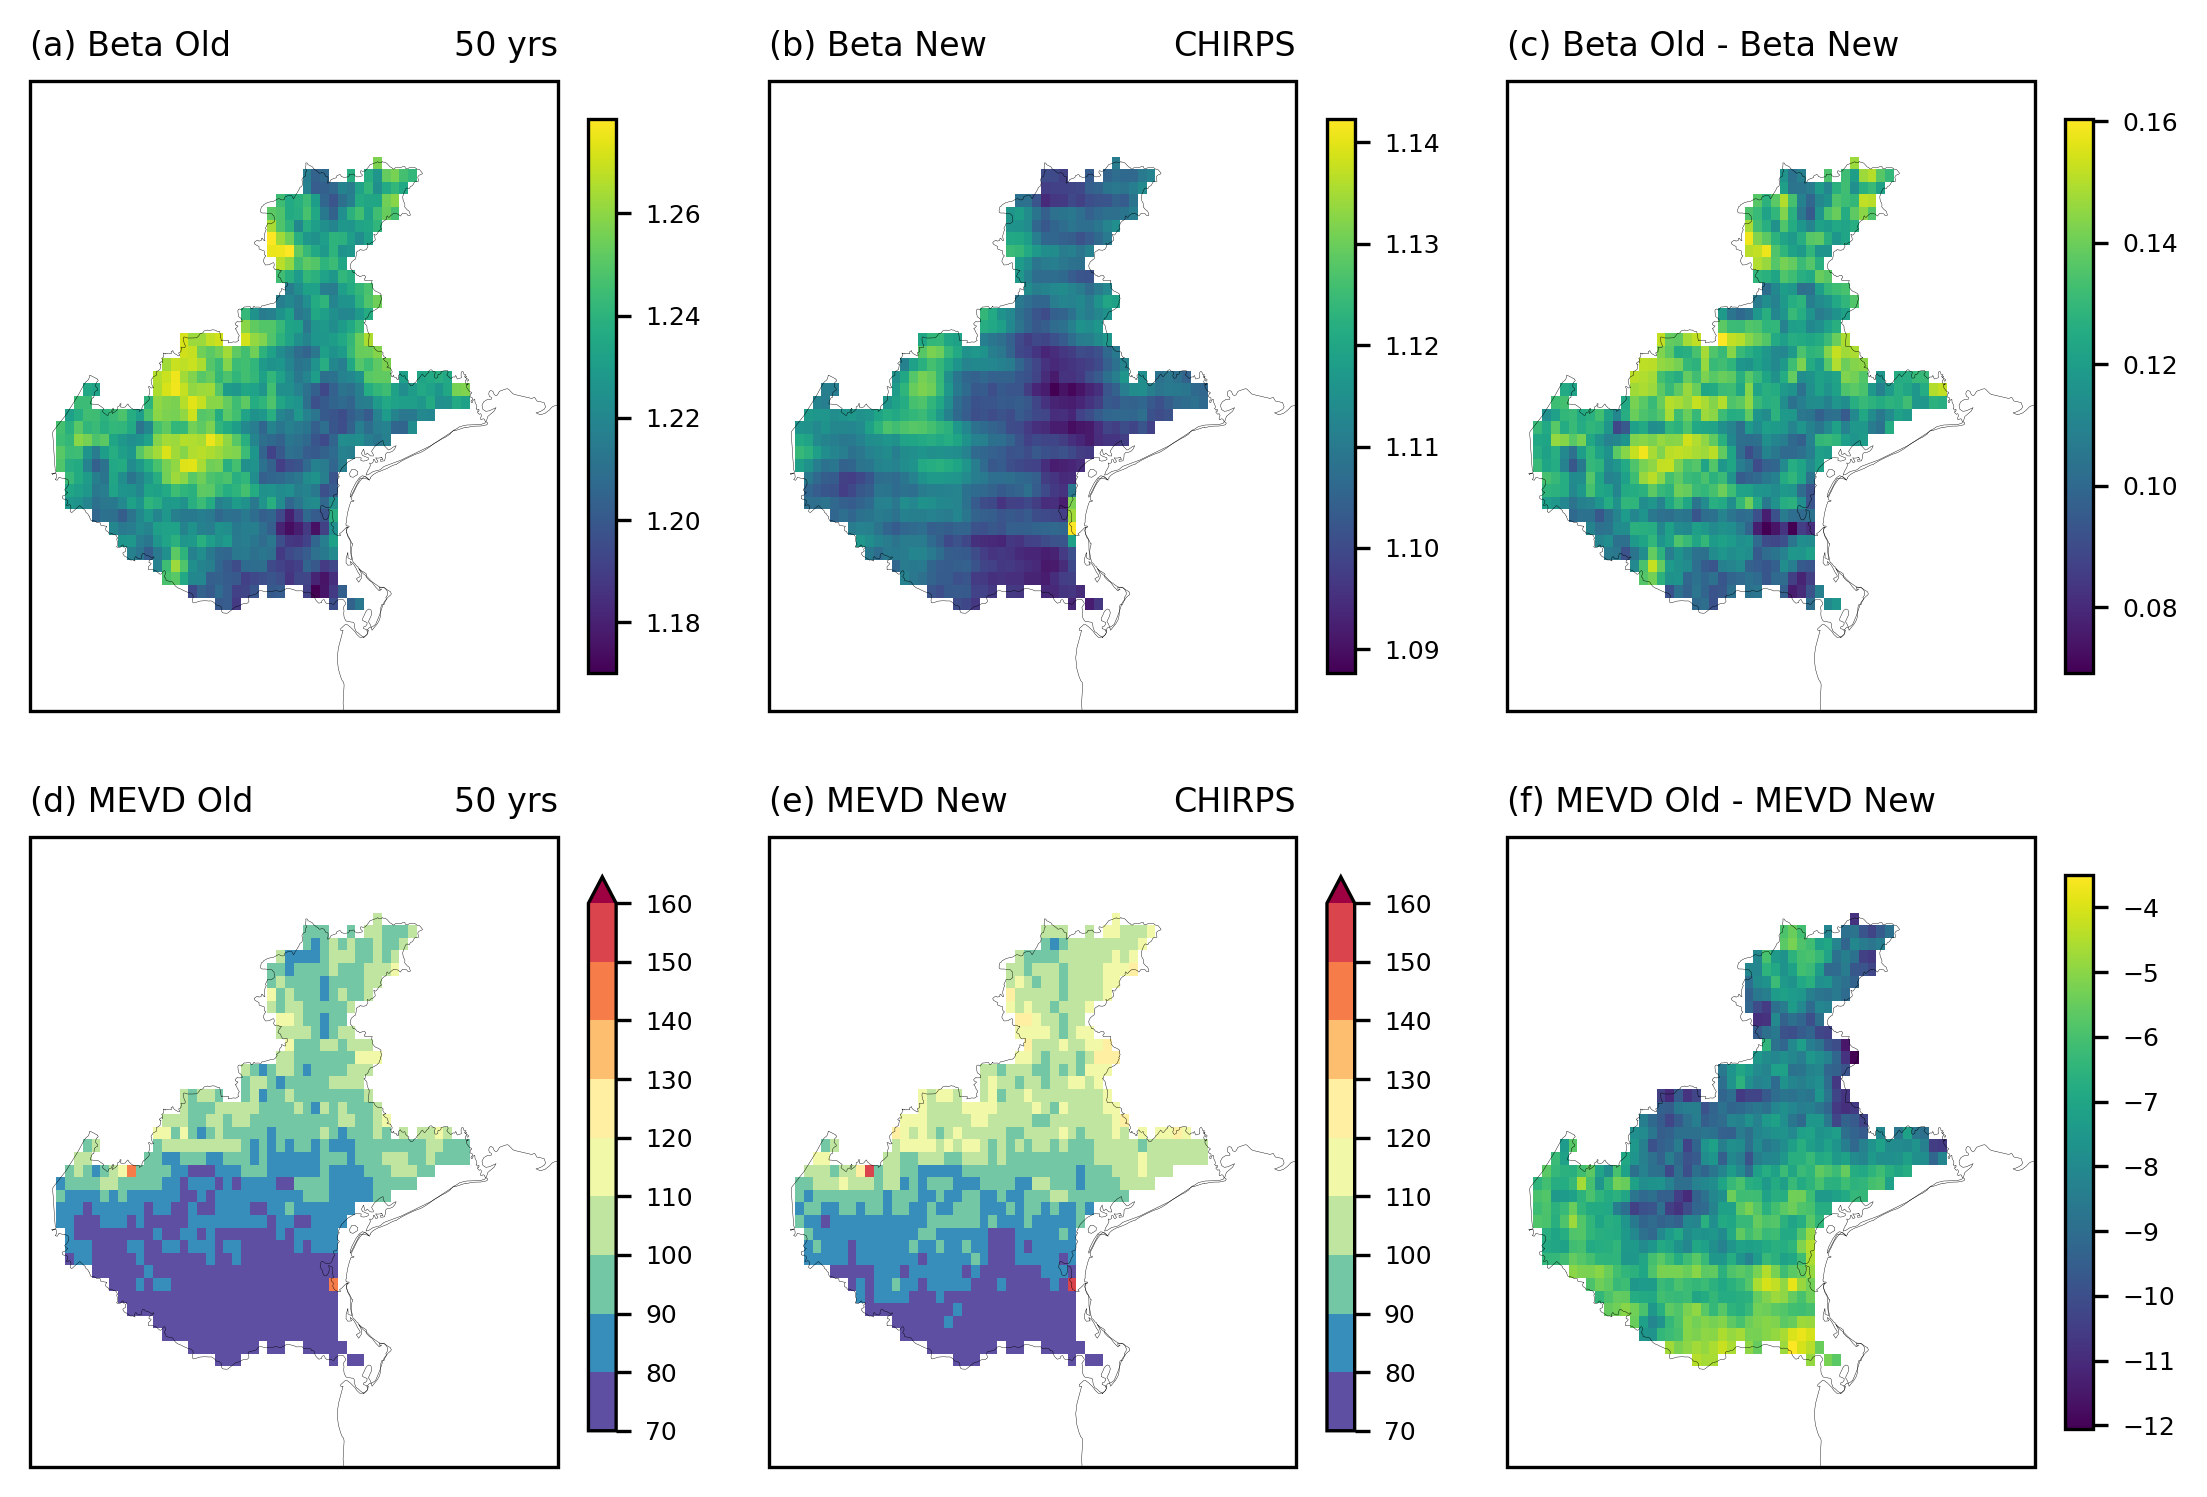

In [142]:
proj = ccrs.PlateCarree()

fig = plt.figure(figsize=(9,6),dpi=300)
gs = gridspec.GridSpec(2,3)

# ========================================================================================================
ax1 = plt.subplot(gs[0, 0], projection = proj)
ax1.set_extent([lon_min, lon_max, lat_min, lat_max], crs=proj)
ax1.add_feature(cfeature.COASTLINE,linewidth=0.1,edgecolor='k')
GEOMETRY.plot(legend=False, facecolor="none", edgecolor='black', linewidth=0.1, ax=ax1, zorder=10)
a1 = ax1.pcolormesh(lon2d, lat2d, BETA_old)
cbar = plt.colorbar(a1, fraction =0.045)
cbar.ax.tick_params(labelsize=6)
ax1.set_title('(a) Beta Old', fontsize=8, loc='left')
ax1.set_title('50 yrs', fontsize=8, loc='right')

# ========================================================================================================
ax1 = plt.subplot(gs[0, 1], projection = proj)
ax1.set_extent([lon_min, lon_max, lat_min, lat_max], crs=proj)
ax1.add_feature(cfeature.COASTLINE,linewidth=0.1,edgecolor='k')
GEOMETRY.plot(legend=False, facecolor="none", edgecolor='black', linewidth=0.1, ax=ax1, zorder=10)
a1 = ax1.pcolormesh(lon2d, lat2d, Beta)
cbar = plt.colorbar(a1, fraction =0.045)
cbar.ax.tick_params(labelsize=6)
ax1.set_title('(b) Beta New', fontsize=8, loc='left')
ax1.set_title(product, fontsize=8, loc='right')

# ========================================================================================================
ax1 = plt.subplot(gs[0, 2], projection = proj)
ax1.set_extent([lon_min, lon_max, lat_min, lat_max], crs=proj)
ax1.add_feature(cfeature.COASTLINE,linewidth=0.1,edgecolor='k')
GEOMETRY.plot(legend=False, facecolor="none", edgecolor='black', linewidth=0.1, ax=ax1, zorder=10)
a1 = ax1.pcolormesh(lon2d, lat2d, BETA_old - Beta)
cbar = plt.colorbar(a1, fraction =0.045)
cbar.ax.tick_params(labelsize=6)
ax1.set_title('(c) Beta Old - Beta New', fontsize=8, loc='left')

# ========================================================================================================
# ========================================================================================================
ax1 = plt.subplot(gs[1, 0], projection = proj)
ax1.set_extent([lon_min, lon_max, lat_min, lat_max], crs=proj)
ax1.add_feature(cfeature.COASTLINE,linewidth=0.1,edgecolor='k')
GEOMETRY.plot(legend=False, facecolor="none", edgecolor='black', linewidth=0.1, ax=ax1, zorder=10)
a1 = ax1.pcolormesh(lon2d, lat2d, MEVD_OLD[3,:,:], norm=norm, cmap=Mev_cmap)
cbar = plt.colorbar(a1, fraction =0.045)
cbar.ax.tick_params(labelsize=6)
ax1.set_title('(d) MEVD Old', fontsize=8, loc='left')
ax1.set_title('50 yrs', fontsize=8, loc='right')

# ========================================================================================================
ax1 = plt.subplot(gs[1, 1], projection = proj)
ax1.set_extent([lon_min, lon_max, lat_min, lat_max], crs=proj)
ax1.add_feature(cfeature.COASTLINE,linewidth=0.1,edgecolor='k')
GEOMETRY.plot(legend=False, facecolor="none", edgecolor='black', linewidth=0.1, ax=ax1, zorder=10)
a1 = ax1.pcolormesh(lon2d, lat2d, MEVD_NEW[3,:,:], norm=norm, cmap=Mev_cmap)
cbar = plt.colorbar(a1, fraction =0.045)
cbar.ax.tick_params(labelsize=6)
ax1.set_title('(e) MEVD New', fontsize=8, loc='left')
ax1.set_title(product, fontsize=8, loc='right')

# ========================================================================================================
ax1 = plt.subplot(gs[1, 2], projection = proj)
ax1.set_extent([lon_min, lon_max, lat_min, lat_max], crs=proj)
ax1.add_feature(cfeature.COASTLINE,linewidth=0.1,edgecolor='k')
GEOMETRY.plot(legend=False, facecolor="none", edgecolor='black', linewidth=0.1, ax=ax1, zorder=10)
a1 = ax1.pcolormesh(lon2d, lat2d, MEVD_OLD[3,:,:] - MEVD_NEW[3,:,:], norm=None, cmap=None)
cbar = plt.colorbar(a1, fraction =0.045)
cbar.ax.tick_params(labelsize=6)
ax1.set_title('(f) MEVD Old - MEVD New', fontsize=8, loc='left')